# Data Collection

In [574]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Suppress warnings
warnings.filterwarnings("ignore")

In [576]:
# Load the dataset
df = pd.read_csv('road_traffic_injuries.csv', encoding='ISO-8859-1')
df

,ind_id,ind_definition,reportyear,geotype,geotypevalue,geoname,county_name,county_fips,region_name,region_code,...,avmttotal,avmtrate,LL95CI_avmtrate,UL95CI_avmtrate,avmtrate_se,avmtrate_rse,CA_decile_avmt,CA_RR_avmtrate,groupquarters,version
0,753,Annual number of fatal and severe road traffic...,2002,CO,6059.0,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55
1,753,Annual number of fatal and severe road traffic...,2002,CO,6059.0,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55
2,753,Annual number of fatal and severe road traffic...,2002,CO,6059.0,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55
3,753,Annual number of fatal and severe road traffic...,2002,CO,6059.0,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55
4,753,Annual number of fatal and severe road traffic...,2002,CO,6059.0,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448945,753,Annual number of fatal and severe road traffic...,2010,PL,80588.0,Truckee town,Nevada,6057.0,Northeast Sierra,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.0,17/12/2013 13:55
448946,753,Annual number of fatal and severe road traffic...,2010,PL,80588.0,Truckee town,Nevada,6057.0,Northeast Sierra,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.0,17/12/2013 13:55
448947,753,Annual number of fatal and severe road traffic...,2010,PL,80588.0,Truckee town,Nevada,6057.0,Northeast Sierra,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.0,17/12/2013 13:55
448948,753,Annual number of fatal and severe road traffic...,2010,PL,80588.0,Truckee town,Nevada,6057.0,Northeast Sierra,6.0,...,35237538.0,28.38,0.0,84.0,28.38,100.0,NaN,1.17,43.0,17/12/2013 13:55


In [578]:
# Display basic information about the dataset
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448950 entries, 0 to 448949
Data columns (total 31 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ind_id           448950 non-null  object 
 1   ind_definition   448948 non-null  object 
 2   reportyear       448948 non-null  object 
 3   geotype          448948 non-null  object 
 4   geotypevalue     448948 non-null  float64
 5   geoname          448948 non-null  object 
 6   county_name      445371 non-null  object 
 7   county_fips      445371 non-null  float64
 8   region_name      94066 non-null   object 
 9   region_code      94066 non-null   float64
 10  mode             448948 non-null  object 
 11  severity         448948 non-null  object 
 12  injuries         447566 non-null  float64
 13  totalpop         333552 non-null  float64
 14  poprate          332643 non-null  float64
 15  LL95CI_poprate   331704 non-null  float64
 16  UL95CI_poprate   331599 

In [580]:
# Display the first few rows
df.head()

,ind_id,ind_definition,reportyear,geotype,geotypevalue,geoname,county_name,county_fips,region_name,region_code,...,avmttotal,avmtrate,LL95CI_avmtrate,UL95CI_avmtrate,avmtrate_se,avmtrate_rse,CA_decile_avmt,CA_RR_avmtrate,groupquarters,version
0,753,Annual number of fatal and severe road traffic...,2002,CO,6059.0,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55
1,753,Annual number of fatal and severe road traffic...,2002,CO,6059.0,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55
2,753,Annual number of fatal and severe road traffic...,2002,CO,6059.0,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55
3,753,Annual number of fatal and severe road traffic...,2002,CO,6059.0,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55
4,753,Annual number of fatal and severe road traffic...,2002,CO,6059.0,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55


In [10]:
df.describe()

,geotypevalue,county_fips,region_code,injuries,totalpop,poprate,LL95CI_poprate,UL95CI_poprate,poprate_se,poprate_rse,...,CA_RR_poprate,avmttotal,avmtrate,LL95CI_avmtrate,UL95CI_avmtrate,avmtrate_se,avmtrate_rse,CA_decile_avmt,CA_RR_avmtrate,groupquarters
count,4.489480e+05,445371.000000,94066.000000,447566.00000,3.335520e+05,3.326430e+05,331704.000000,331599.000000,324654.000000,311543.000000,...,275365.000000,2.180800e+04,21266.000000,21266.000000,21266.000000,21266.000000,21266.000000,859.000000,21266.000000,121521.000000
mean,4.816763e+09,6055.795018,8.762082,6.79757,6.080408e+05,9.620251e+03,9.200426,38.037243,9.320580,58.465875,...,2.635943,4.454637e+09,49.040880,21.148655,85.329755,18.514661,35.522490,5.500582,2.093846,13286.392360
std,3.169910e+09,27.275320,4.892614,122.88827,9.413326e+05,1.269842e+05,29.117388,390.004628,135.573836,59.311216,...,23.344528,1.816027e+10,99.317081,43.827419,220.595641,67.470516,35.082377,2.869084,4.103498,37797.862339
min,1.000000e+00,6001.000000,1.000000,0.20000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.010000,0.010000,...,0.030000,0.000000e+00,0.670000,0.000000,1.610000,0.140000,0.860000,1.000000,0.090000,0.000000
25%,6.011000e+09,6037.000000,4.000000,0.67000,4.459333e+04,1.810000e+00,0.000000,3.360000,0.600000,15.250000,...,0.690000,1.407871e+08,14.460000,1.412500,22.980000,2.440000,10.620000,3.000000,0.980000,458.000000
50%,6.037573e+09,6059.000000,10.000000,1.00000,2.558250e+05,6.580000e+00,1.100000,12.540000,1.760000,35.360000,...,1.110000,5.705526e+08,30.505000,10.740000,44.760000,6.480000,22.360000,6.000000,1.400000,3142.000000
75%,6.071009e+09,6073.000000,14.000000,2.00000,7.051140e+05,2.336000e+01,10.130000,36.400000,6.770000,86.600000,...,1.860000,3.624192e+09,50.637500,29.640000,75.540000,15.080000,50.000000,8.000000,2.060000,15533.000000
max,1.000000e+11,6115.000000,14.000000,13578.00000,1.805153e+07,3.048563e+06,4368.360000,84784.350000,29992.020000,254.030000,...,5182.950000,3.360000e+11,4949.820000,770.840000,11809.920000,3500.050000,223.610000,10.000000,246.050000,834673.000000


In [12]:
df.shape

(448950, 31)

In [14]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
ind_id                  0
ind_definition          2
reportyear              2
geotype                 2
geotypevalue            2
geoname                 2
county_name          3579
county_fips          3579
region_name        354884
region_code        354884
mode                    2
severity                2
injuries             1384
totalpop           115398
poprate            116307
LL95CI_poprate     117246
UL95CI_poprate     117351
poprate_se         124296
poprate_rse        137407
CA_decile_pop      438344
CA_RR_poprate      173585
avmttotal          427142
avmtrate           427684
LL95CI_avmtrate    427684
UL95CI_avmtrate    427684
avmtrate_se        427684
avmtrate_rse       427684
CA_decile_avmt     448091
CA_RR_avmtrate     427684
groupquarters      327429
version                 2
dtype: int64


In [16]:
# Calculate percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Display the missing values percentage
print(missing_percentage)

ind_id              0.000000
ind_definition      0.000445
reportyear          0.000445
geotype             0.000445
geotypevalue        0.000445
geoname             0.000445
county_name         0.797193
county_fips         0.797193
region_name        79.047555
region_code        79.047555
mode                0.000445
severity            0.000445
injuries            0.308275
totalpop           25.703976
poprate            25.906448
LL95CI_poprate     26.115603
UL95CI_poprate     26.138991
poprate_se         27.685934
poprate_rse        30.606304
CA_decile_pop      97.637599
CA_RR_poprate      38.664662
avmttotal          95.142443
avmtrate           95.263170
LL95CI_avmtrate    95.263170
UL95CI_avmtrate    95.263170
avmtrate_se        95.263170
avmtrate_rse       95.263170
CA_decile_avmt     99.808665
CA_RR_avmtrate     95.263170
groupquarters      72.932175
version             0.000445
dtype: float64


In [18]:
# Remove columns with 40% or more missing values
df_cleaned = df.loc[:, missing_percentage < 40]

# Display the updated dataset
print("Columns removed:", missing_percentage[missing_percentage >= 40].index.tolist())
print("Updated dataset shape:", df_cleaned.shape)

Columns removed: ['region_name', 'region_code', 'CA_decile_pop', 'avmttotal', 'avmtrate', 'LL95CI_avmtrate', 'UL95CI_avmtrate', 'avmtrate_se', 'avmtrate_rse', 'CA_decile_avmt', 'CA_RR_avmtrate', 'groupquarters']
Updated dataset shape: (448950, 19)


In [20]:
# Fill missing values with mean (for numeric) or mode (for categorical) if missing percentage is below 40%
for col in df_cleaned.columns:
    if df_cleaned[col].isnull().sum() > 0:
        if df_cleaned[col].dtype in ['int64', 'float64']:
            df_cleaned[col].fillna(df_cleaned[col].mean(), inplace=True)  # Fill with mean
        else:
            df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)  # Fill with mode for categorical

# Display the updated dataset
print("Columns removed:", missing_percentage[missing_percentage >= 40].index.tolist())
print("Updated dataset shape:", df_cleaned.shape)

# Save cleaned dataset
df_cleaned.to_csv("cleaned_dataset.csv", index=False)

Columns removed: ['region_name', 'region_code', 'CA_decile_pop', 'avmttotal', 'avmtrate', 'LL95CI_avmtrate', 'UL95CI_avmtrate', 'avmtrate_se', 'avmtrate_rse', 'CA_decile_avmt', 'CA_RR_avmtrate', 'groupquarters']
Updated dataset shape: (448950, 19)


In [22]:
# reLoad the dataset after removing missing value columns
df = pd.read_csv('cleaned_dataset.csv', encoding='ISO-8859-1')
df

,ind_id,ind_definition,reportyear,geotype,geotypevalue,geoname,county_name,county_fips,mode,severity,injuries,totalpop,poprate,LL95CI_poprate,UL95CI_poprate,poprate_se,poprate_rse,CA_RR_poprate,version
0,753,Annual number of fatal and severe road traffic...,2002,CO,6.059000e+03,Orange,Orange,6059.000000,All modes,Killed,193.00000,2.914663e+06,6.620000,5.690000,7.560000,0.48000,7.200000,0.570000,17/12/2013 13:55
1,753,Annual number of fatal and severe road traffic...,2002,CO,6.059000e+03,Orange,Orange,6059.000000,All modes,Severe Injury,721.00000,2.914663e+06,24.740000,22.930000,26.540000,0.92000,3.720000,0.640000,17/12/2013 13:55
2,753,Annual number of fatal and severe road traffic...,2002,CO,6.059000e+03,Orange,Orange,6059.000000,Bicyclist,Killed,7.00000,2.914663e+06,0.240000,0.060000,0.420000,0.09000,37.800000,0.950000,17/12/2013 13:55
3,753,Annual number of fatal and severe road traffic...,2002,CO,6.059000e+03,Orange,Orange,6059.000000,Bicyclist,Severe Injury,49.00000,2.914663e+06,1.680000,1.210000,2.150000,0.24000,14.290000,1.020000,17/12/2013 13:55
4,753,Annual number of fatal and severe road traffic...,2002,CO,6.059000e+03,Orange,Orange,6059.000000,Bus,Severe Injury,1.00000,2.914663e+06,0.030000,0.000000,0.100000,0.03000,100.000000,0.540000,17/12/2013 13:55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448945,753,Annual number of fatal and severe road traffic...,2010,PL,8.058800e+04,Truckee town,Nevada,6057.000000,All modes,Severe Injury,2.00000,1.618000e+04,12.360000,0.000000,29.490000,8.74000,70.710000,0.440000,17/12/2013 13:55
448946,753,Annual number of fatal and severe road traffic...,2010,PL,8.058800e+04,Truckee town,Nevada,6057.000000,Car/Pickup,Severe Injury,1.00000,1.618000e+04,6.180000,0.000000,18.290000,6.18000,100.000000,0.390000,17/12/2013 13:55
448947,753,Annual number of fatal and severe road traffic...,2010,PL,8.058800e+04,Truckee town,Nevada,6057.000000,Pedestrian,Severe Injury,1.00000,1.618000e+04,6.180000,0.000000,18.290000,6.18000,100.000000,1.300000,17/12/2013 13:55
448948,753,Annual number of fatal and severe road traffic...,2010,PL,8.058800e+04,Truckee town,Nevada,6057.000000,Vehicles,Severe Injury,1.00000,1.618000e+04,6.180000,0.000000,18.290000,6.18000,100.000000,0.290000,17/12/2013 13:55


In [24]:
# Check if any missing values remain
print("\nMissing Values After Imputation:")
print(df_cleaned.isnull().sum())


Missing Values After Imputation:
ind_id            0
ind_definition    0
reportyear        0
geotype           0
geotypevalue      0
geoname           0
county_name       0
county_fips       0
mode              0
severity          0
injuries          0
totalpop          0
poprate           0
LL95CI_poprate    0
UL95CI_poprate    0
poprate_se        0
poprate_rse       0
CA_RR_poprate     0
version           0
dtype: int64


In [26]:
#Define a function to remove outliers
def remove_outliers(df, column):
   
    Q1 = df[column].quantile(0.25)  # First quartile (25th percentile)
    Q3 = df[column].quantile(0.75)  # Third quartile (75th percentile)
    IQR = Q3 - Q1  # Interquartile range

    # Define lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter the DataFrame
    df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    return df_cleaned

# Example usage on 'poprate'
df_cleaned = remove_outliers(df, 'poprate')

# Display the number of removed rows
print(f"Rows before: {len(df)}, Rows after outlier removal: {len(df_cleaned)}")


Rows before: 448950, Rows after outlier removal: 445108


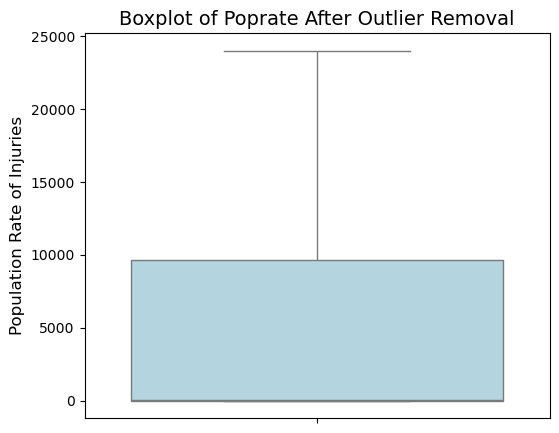

In [28]:
# Remove outliers from 'poprate'
df_outliers_removed = remove_outliers(df, 'poprate')

# Plot boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(y=df_outliers_removed['poprate'], color='lightblue')

# Labels and title
plt.ylabel("Population Rate of Injuries", fontsize=12)
plt.title("Boxplot of Poprate After Outlier Removal", fontsize=14)

# Show the plot
plt.show()

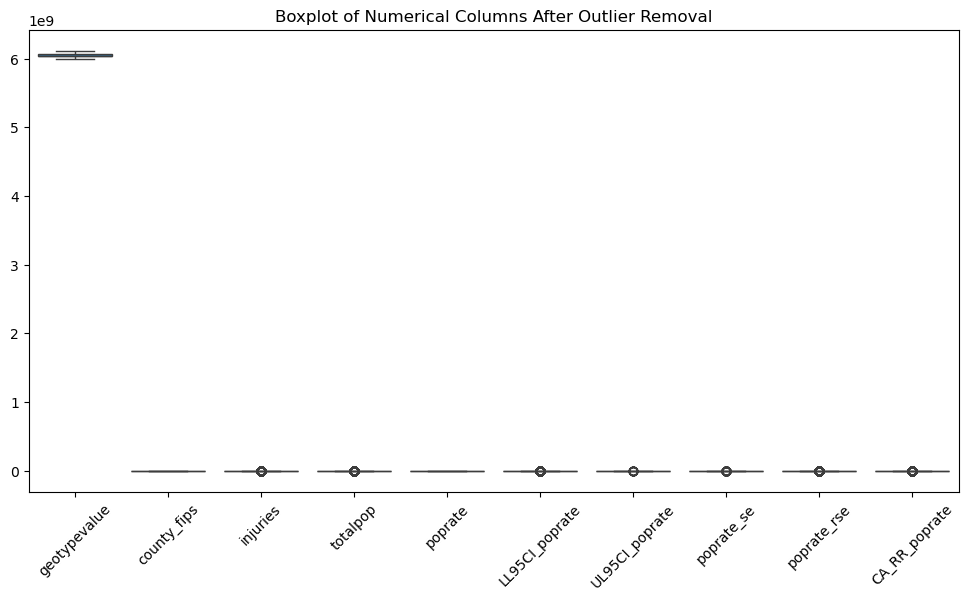

In [32]:
#To create a boxplot of all columns after outlier removal,
# Identify numerical columns
numeric_cols = df.select_dtypes(include=['number'])

# Outlier removal using IQR
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

# Ensure 'numeric_cols' is defined before filtering
df_cleaned = numeric_cols[~((numeric_cols < (Q1 - 1.5 * IQR)) | (numeric_cols > (Q3 + 1.5 * IQR))).any(axis=1)]

# Plot boxplots after outlier removal
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned)
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Columns After Outlier Removal")
plt.show()

In [34]:
# Check skewness in numerical features
numerical_cols = df_cleaned.select_dtypes(include=[np.number]).columns
skewed_features = df_cleaned[numerical_cols].apply(lambda x: x.skew()).sort_values(ascending=False)
print("\nSkewness in Features:")
print(skewed_features)


Skewness in Features:
injuries          1.118388
county_fips       0.347337
geotypevalue      0.346922
LL95CI_poprate    0.328207
totalpop          0.247462
poprate_se        0.231833
poprate           0.201882
poprate_rse       0.081418
UL95CI_poprate   -0.092724
CA_RR_poprate    -0.502359
dtype: float64


In [36]:
# Apply log transformation to reduce skewness
for feature in skewed_features.index:
    if abs(skewed_features[feature]) > 1:  # Apply only to highly skewed features
        df_cleaned.loc[:, feature] = np.log1p(df_cleaned[feature])

In [38]:
print("\nBefore Transformation:\n", df_cleaned[feature].describe())
df_cleaned[feature] = np.log1p(df_cleaned[feature])
print("\nAfter Transformation:\n", df_cleaned[feature].describe())


Before Transformation:
 count    207542.000000
mean          2.079686
std           0.869203
min           0.080000
25%           1.220000
50%           2.635943
75%           2.635943
max           5.170000
Name: CA_RR_poprate, dtype: float64

After Transformation:
 count    207542.000000
mean          1.076092
std           0.329525
min           0.076961
25%           0.797507
50%           1.290869
75%           1.290869
max           1.819699
Name: CA_RR_poprate, dtype: float64


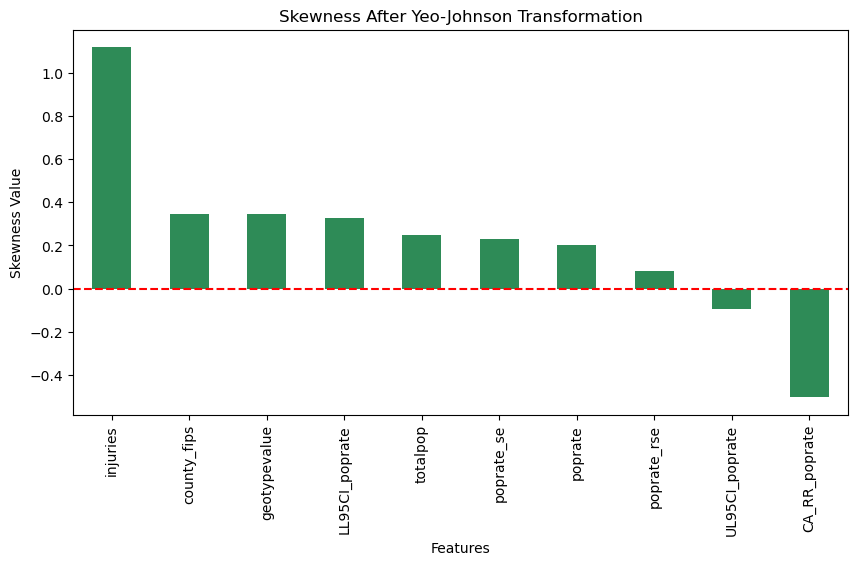

In [40]:
 #Visualizing Skewness After Transformation
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
skewed_features.plot(kind='bar', color='seagreen')
plt.axhline(y=0, color='r', linestyle='--')  # Reference line at 0 (no skew)
plt.title("Skewness After Yeo-Johnson Transformation")
plt.xlabel("Features")
plt.ylabel("Skewness Value")
plt.show()

In [42]:
# Define target variable (dependent variable)
target = 'poprate'  # Change this if needed

# Separate features (X) and target (y)
X = df_cleaned.drop(columns=[target])  # Independent variables
y = df_cleaned[target]  # Dependent variable

# Display shapes
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Display first few rows of features and target
print("First few rows of features (X):")
print(X.head())

print("\nFirst few values of target (y):")
print(y.head())


Features (X) shape: (207542, 9)
Target (y) shape: (207542,)
First few rows of features (X):
      geotypevalue  county_fips  injuries  totalpop  LL95CI_poprate  \
4897  6.063000e+09       6063.0  1.098612   68356.0        9.200426   
4898  6.069000e+09       6069.0  1.386294   68356.0        9.200426   
4899  6.077000e+09       6077.0  0.693147   68356.0        9.200426   
4901  6.107000e+09       6107.0  0.693147   68356.0        9.200426   
4903  6.073000e+09       6073.0  0.693147   68356.0        9.200426   

      UL95CI_poprate  poprate_se  poprate_rse  CA_RR_poprate  
4897       38.037243     9.32058    58.465875       1.290869  
4898       38.037243     9.32058    58.465875       1.290869  
4899       38.037243     9.32058    58.465875       1.290869  
4901       38.037243     9.32058    58.465875       1.290869  
4903       38.037243     9.32058    58.465875       1.290869  

First few values of target (y):
4897    34.37
4898     0.12
4899     2.92
4901    19.43
4903     7.29


In [44]:
#Using Correlation Analysis (Pearson's Correlation)import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
correlation_matrix = df_cleaned.corr()

# Sort correlation values with target variable
correlation_target = correlation_matrix['poprate'].sort_values(ascending=False)

# Display top correlated features
print("Feature Correlation with Target (poprate):")
print(correlation_target)

Feature Correlation with Target (poprate):
poprate           1.000000
poprate_se        0.752298
UL95CI_poprate    0.744156
CA_RR_poprate     0.589622
LL95CI_poprate    0.512009
totalpop          0.379357
poprate_rse       0.315040
injuries         -0.004995
geotypevalue     -0.486424
county_fips      -0.489236
Name: poprate, dtype: float64


Skewness of Numerical Features:
geotypevalue      0.346922
county_fips       0.347337
injuries          0.436876
totalpop          0.247462
poprate           0.201882
LL95CI_poprate    0.328207
UL95CI_poprate   -0.092724
poprate_se        0.231833
poprate_rse       0.081418
CA_RR_poprate    -0.924467
dtype: float64


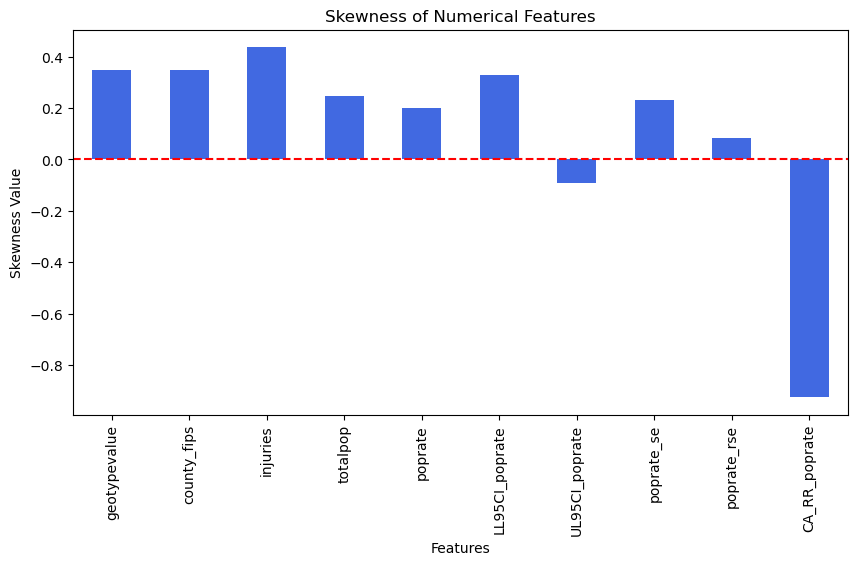

In [46]:
# Calculate skewness for all numerical features
skewness_values = df_cleaned.skew()

# Display skewness values
print("Skewness of Numerical Features:")
print(skewness_values)

# Visualizing skewness using a bar plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
skewness_values.plot(kind='bar', color='royalblue')
plt.axhline(y=0, color='r', linestyle='--')  # Reference line at 0 (no skew)
plt.title("Skewness of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Skewness Value")
plt.show()

# Exploratory Data Analysis

In [48]:
 # Summary statistics for numerical columns
df.describe()

,geotypevalue,county_fips,injuries,totalpop,poprate,LL95CI_poprate,UL95CI_poprate,poprate_se,poprate_rse,CA_RR_poprate
count,4.489500e+05,448950.000000,448950.000000,4.489500e+05,4.489500e+05,448950.000000,448950.000000,448950.000000,448950.000000,448950.000000
mean,4.816763e+09,6055.795018,6.797570,6.080408e+05,9.620251e+03,9.200426,38.037243,9.320580,58.465875,2.635943
std,3.169903e+09,27.166384,122.698706,8.113827e+05,1.093049e+05,25.028142,335.179314,115.288793,49.407926,18.282693
min,1.000000e+00,6001.000000,0.200000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.010000,0.010000,0.030000
25%,6.011000e+09,6037.000000,0.670000,6.131600e+04,3.190000e+00,0.000000,5.380000,0.940000,21.320000,0.940000
50%,6.037573e+09,6059.000000,1.000000,4.807920e+05,1.599000e+01,5.590000,27.720000,4.590000,58.465875,2.360000
75%,6.071009e+09,6073.000000,2.000000,6.080408e+05,9.620251e+03,9.200426,38.037243,9.320580,58.465875,2.635943
max,1.000000e+11,6115.000000,13578.000000,1.805153e+07,3.048563e+06,4368.360000,84784.350000,29992.020000,254.030000,5182.950000


In [50]:
 # Summary for categorical columns
df.describe(include=['object'])

,ind_id,ind_definition,reportyear,geotype,geoname,county_name,mode,severity,version
count,448950,448950,448950,448950,448950,448950,448950,448950,448950
unique,3,1,13,6,13467,58,9,3,1
top,753,Annual number of fatal and severe road traffic...,2006-2010,CT,2,Los Angeles,All modes,Severe Injury,17/12/2013 13:55
freq,393216,448950,59396,354078,921,112467,126487,302487,448950


<Figure size 1200x600 with 0 Axes>

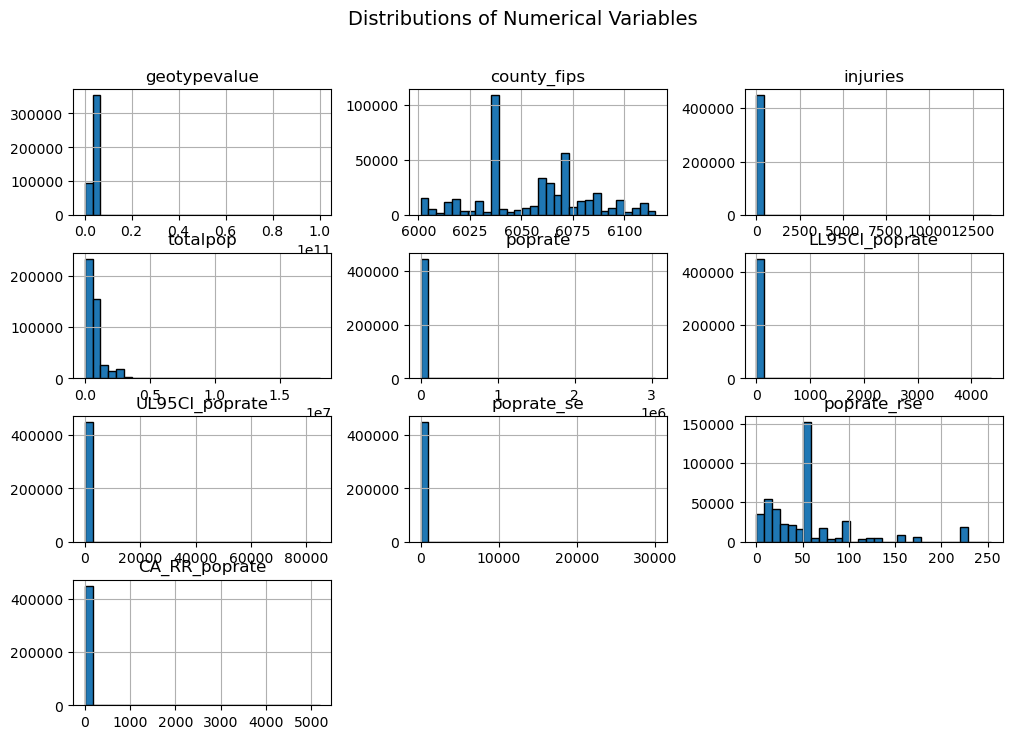

In [52]:
#Distributions of Numerical Variables
plt.figure(figsize=(12, 6))
df.hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle("Distributions of Numerical Variables", fontsize=14)
plt.show()

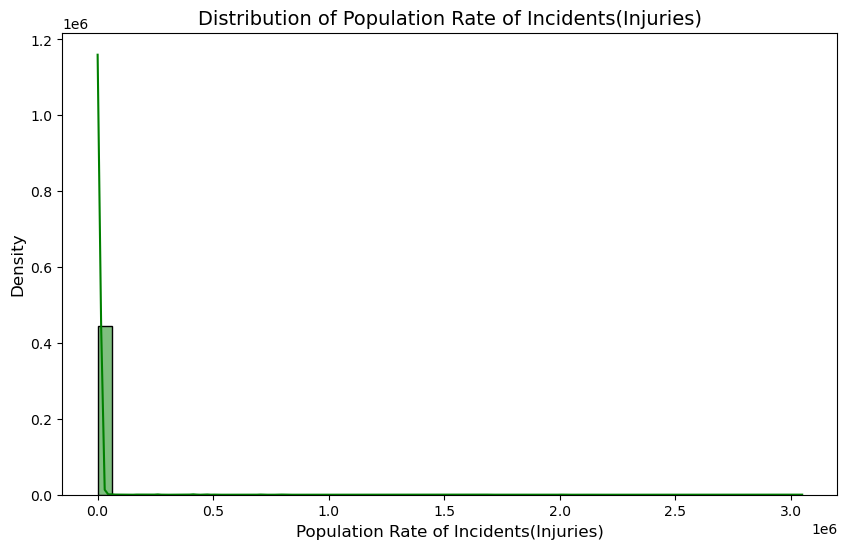

In [54]:
# Distribution of Target Variable

# Set figure size
plt.figure(figsize=(10, 6))

# Plot the distribution of the target variable
sns.histplot(df['poprate'].dropna(), bins=50, kde=True, color='green')

# Add labels and title
plt.xlabel("Population Rate of Incidents(Injuries)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Distribution of Population Rate of Incidents(Injuries)", fontsize=14)

# Show the plot
plt.show()

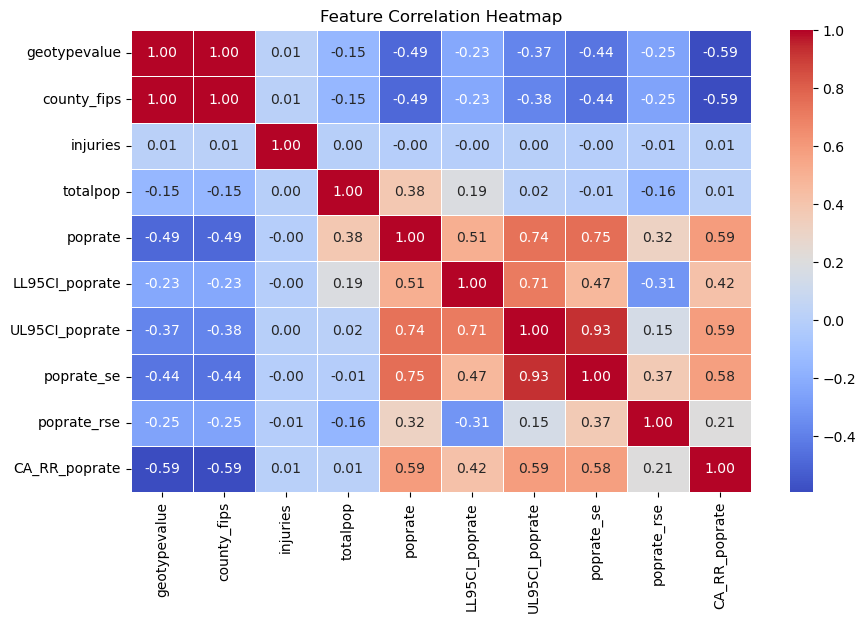

In [56]:
# Visualizing correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature Engineering

## Identify and encode categorical features using techniques  one-hot encoding

In [58]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", categorical_cols)
 #Exclude high-cardinality columns
columns_to_encode = ['ind_id', 'geotype', 'region_name', 'mode', 'severity']



Categorical Columns: ['ind_id', 'ind_definition', 'reportyear', 'geotype', 'geoname', 'county_name', 'mode', 'severity', 'version']


In [62]:
print(df.columns)


Index(['ind_id', 'ind_definition', 'reportyear', 'geotype', 'geotypevalue',
       'geoname', 'county_name', 'county_fips', 'mode', 'severity', 'injuries',
       'totalpop', 'poprate', 'LL95CI_poprate', 'UL95CI_poprate', 'poprate_se',
       'poprate_rse', 'CA_RR_poprate', 'version'],
      dtype='object')


In [64]:
print(columns_to_encode)


['ind_id', 'geotype', 'region_name', 'mode', 'severity']


In [66]:
columns_to_encode = [col for col in columns_to_encode if col in df.columns]
df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)


In [68]:
# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)
# Display the first few rows of the encoded dataframe
df_encoded.head()

,ind_definition,reportyear,geotypevalue,geoname,county_name,county_fips,injuries,totalpop,poprate,LL95CI_poprate,...,mode_Bicyclist,mode_Bus,mode_Car/Pickup,mode_Motorcycle,mode_ND,mode_Pedestrian,mode_Truck,mode_Vehicles,severity_ND,severity_Severe Injury
0,Annual number of fatal and severe road traffic...,2002,6059.0,Orange,Orange,6059.0,193.0,2914663.0,6.62,5.69,...,False,False,False,False,False,False,False,False,False,False
1,Annual number of fatal and severe road traffic...,2002,6059.0,Orange,Orange,6059.0,721.0,2914663.0,24.74,22.93,...,False,False,False,False,False,False,False,False,False,True
2,Annual number of fatal and severe road traffic...,2002,6059.0,Orange,Orange,6059.0,7.0,2914663.0,0.24,0.06,...,True,False,False,False,False,False,False,False,False,False
3,Annual number of fatal and severe road traffic...,2002,6059.0,Orange,Orange,6059.0,49.0,2914663.0,1.68,1.21,...,True,False,False,False,False,False,False,False,False,True
4,Annual number of fatal and severe road traffic...,2002,6059.0,Orange,Orange,6059.0,1.0,2914663.0,0.03,0.00,...,False,True,False,False,False,False,False,False,False,True


# Feature Selection

In [70]:
# Splitting the dataset into training and testing sets
X = df.drop('poprate', axis=1)
y = df['poprate']

In [82]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = ['ind_id', 'ind_definition', 'reportyear', 'geotype', 
                       'geoname', 'county_name', 'region_name', 'mode', 
                       'severity', 'version']

label_encoders = {}  # Optional: store encoders if needed later

for col in categorical_columns:
    if col in X.columns:
        encoder = LabelEncoder()
        X[col] = encoder.fit_transform(X[col].astype(str))  # Ensure values are strings
        label_encoders[col] = encoder
    else:
        print(f"Column '{col}' not found in DataFrame.")

# Check transformed data
print(X.head())


Column 'region_name' not found in DataFrame.
   ind_id  ind_definition  reportyear  geotype  geotypevalue  geoname  \
0       0               0           0        1        6059.0     8273   
1       0               0           0        1        6059.0     8273   
2       0               0           0        1        6059.0     8273   
3       0               0           0        1        6059.0     8273   
4       0               0           0        1        6059.0     8273   

   county_name  county_fips  mode  severity  injuries   totalpop  \
0           15       6059.0     0         0     193.0  2914663.0   
1           15       6059.0     0         2     721.0  2914663.0   
2           15       6059.0     1         0       7.0  2914663.0   
3           15       6059.0     1         2      49.0  2914663.0   
4           15       6059.0     2         2       1.0  2914663.0   

   LL95CI_poprate  UL95CI_poprate  poprate_se  poprate_rse  CA_RR_poprate  \
0            5.69            7

In [84]:
from sklearn.feature_selection import SelectKBest, f_regression
import pandas as pd

# Convert datetime columns to numerical values
def preprocess_data(X):
    X = X.copy()  # Avoid modifying the original DataFrame
    for col in X.select_dtypes(include=['datetime64']):
        X[col] = X[col].astype('int64') // 10**9  # Convert to Unix timestamp (seconds)
    return X

# Function to select best K features for regression
def select_best_features(X, y, K=10):
    X = preprocess_data(X)  # Convert datetime columns
    
    # Handle missing values (choose one approach)
    X = X.fillna(X.median())  # Option 1: Fill NaNs with median
    # X = X.dropna()  # Option 2: Drop rows with NaNs
    # y = y.loc[X.index]  # Ensure y is aligned if dropping NaNs

    # Ensure K is not greater than available features
    K = min(K, X.shape[1])

    selector = SelectKBest(score_func=f_regression, k=K)
    X_new = selector.fit_transform(X, y)
    
    # Get feature scores
    feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
    feature_scores = feature_scores.sort_values(by='Score', ascending=False).reset_index(drop=True)
    
    print("Top Selected Features:\n", feature_scores.head(K))
    
    return X_new, feature_scores

# Set K (number of top features to select)
K = 10

# Preprocess and Apply feature selection
X_selected, feature_scores = select_best_features(X, y, K)

# Print all feature scores (optional)
print("\nAll Feature Scores:\n", feature_scores)


Top Selected Features:
           Feature        Score
0         geotype  3983.240252
1    geotypevalue  3448.472955
2     poprate_rse  2607.391705
3         geoname  2427.904360
4     county_name  2275.145552
5     county_fips  1739.856725
6        totalpop  1078.802878
7      reportyear   732.669924
8        severity    19.433761
9  UL95CI_poprate    10.626266

All Feature Scores:
            Feature        Score
0          geotype  3983.240252
1     geotypevalue  3448.472955
2      poprate_rse  2607.391705
3          geoname  2427.904360
4      county_name  2275.145552
5      county_fips  1739.856725
6         totalpop  1078.802878
7       reportyear   732.669924
8         severity    19.433761
9   UL95CI_poprate    10.626266
10   CA_RR_poprate     3.282099
11        injuries     2.119365
12      poprate_se     1.438914
13            mode     0.433856
14  LL95CI_poprate     0.132908
15          ind_id     0.003873
16  ind_definition     0.000000
17         version     0.000000


# Feature Scaling

In [86]:
from sklearn.preprocessing import StandardScaler

# Selecting only numerical columns to scale from df (replace df with your dataset name)
df_numeric = df.select_dtypes(include=['number'])  

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling
x_scaled = scaler.fit_transform(df_numeric)

# Convert back to DataFrame
df_scaled = pd.DataFrame(x_scaled, columns=df_numeric.columns)

print("Standard Scaled Data (First 5 Rows):")
print(df_scaled.head())

Standard Scaled Data (First 5 Rows):
   geotypevalue  county_fips  injuries  totalpop   poprate  LL95CI_poprate  \
0      -1.51953     0.117976  1.517560  2.842832 -0.087953       -0.140259   
1      -1.51953     0.117976  5.820789  2.842832 -0.087787        0.548566   
2      -1.51953     0.117976  0.001650  2.842832 -0.088011       -0.365206   
3      -1.51953     0.117976  0.343952  2.842832 -0.087998       -0.319258   
4      -1.51953     0.117976 -0.047251  2.842832 -0.088013       -0.367604   

   UL95CI_poprate  poprate_se  poprate_rse  CA_RR_poprate  
0       -0.090928   -0.076682    -1.037605      -0.113000  
1       -0.034302   -0.072866    -1.108040      -0.109171  
2       -0.112230   -0.080065    -0.418271      -0.092215  
3       -0.107069   -0.078764    -0.894106      -0.088387  
4       -0.113185   -0.080585     0.840638      -0.114641  


## Splitting the dataset into training (80%) and testing (20%) sets

In [88]:

from sklearn.model_selection import train_test_split

# Assuming df is your dataset and 'target_variable' is the dependent variable
X = df.drop(columns=['poprate'])  # Independent features
y = df['poprate']  # Target variable

# Splitting the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display shapes of the resulting sets
print(f"Training set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing set: X_test = {X_test.shape}, y_test = {y_test.shape}")

Training set: X_train = (359160, 18), y_train = (359160,)
Testing set: X_test = (89790, 18), y_test = (89790,)


# Build the ML Model

In [90]:
# Import necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Regression Models Dictionary
models={
    '1.Linear Regression':LinearRegression(),
    '2.Decision Tree Regressor':DecisionTreeRegressor(),
    '3.Random Forest Regressor':RandomForestRegressor(),
    '4.Gradient Boosting Regressor':GradientBoostingRegressor(),
    '5.Support Vector Regressor':SVR()
}


# Model Evaluation

In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
results = {}

for model_name, model in models.items():
    # Fit the model
    model.fit(X_train_scaled, y_train)
    # Make the prediction
    y_pred = model.predict(X_test_scaled)
    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    # Store the results
    results[model_name] = {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}


In [142]:
# Convert results to DataFrame and display
results_df = pd.DataFrame(results).T
print(results_df)

                                    MSE       MAE      RMSE        R2
1.Linear Regression            0.037114  0.146377  0.192649  0.946896
2.Decision Tree Regressor      0.000000  0.000000  0.000000  1.000000
3.Random Forest Regressor      0.001143  0.011667  0.033813  0.998364
4.Gradient Boosting Regressor  0.006130  0.036339  0.078296  0.991228
5.Support Vector Regressor     0.026840  0.136949  0.163829  0.961596


In [160]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# R² Score
print("R² Score (Train):", r2_score(y_train, pred_train))
print("R² Score (Test):", r2_score(y_test, y_pred_dt))

# Mean Squared Error
print("MSE (Test):", mean_squared_error(y_test, y_pred_dt))

# Mean Absolute Error
print("MAE (Test):", mean_absolute_error(y_test, y_pred_dt))


R² Score (Train): 0.9558085482846607
R² Score (Test): 0.9615962412420096
MSE (Test): 0.026839960287528865
MAE (Test): 0.1369486399316327


In [162]:
# Ensure predictions are integers
y_pred_class = y_pred.astype(int)
pred_train_class = pred_train.astype(int)

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

print("Accuracy score on test data:", accuracy_score(y_test, y_pred_class))
print("Accuracy score on training data:", accuracy_score(y_train, pred_train_class))


Accuracy score on test data: 0.6666666666666666
Accuracy score on training data: 0.6083333333333333


In [168]:

# Accuracy Score
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy (Test Data):", accuracy_dt)


Decision Tree Accuracy (Test Data): 0.6666666666666666


# Finding best model

In [170]:
best_model = results_df['R2'].idxmax()
print(f'The best Model based on R2 Score is:\n {best_model}')
print(results_df.loc[best_model])

The best Model based on R2 Score is:
 2.Decision Tree Regressor
MSE     0.0
MAE     0.0
RMSE    0.0
R2      1.0
Name: 2.Decision Tree Regressor, dtype: float64


In [174]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), param_grid, cv=5)
ridge_grid.fit(X_train, y_train)

print(f"Best Ridge Alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best Ridge R² Score: {ridge_grid.best_estimator_.score(X_test, y_test)}")


Best Ridge Alpha: 1
Best Ridge R² Score: 0.9440579987200234


# Hyperparameter Tuning and Pipeline

In [178]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

#Define a hyperparameter grid for  Tuning Decision Tree Regressor
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}




In [204]:
# Initialize GridSearchCV
tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)
# Fit the model
tree_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [3, 5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

In [184]:
# Best parameters and performance
print(f"Best Parameters: {tree_grid.best_params_}")
print(f"Best R² Score on Test Data: {tree_grid.best_estimator_.score(X_test, y_test)}")

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best R² Score on Test Data: 0.9876480321858473


In [188]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Train the best decision tree model
best_dt = tree_grid.best_estimator_  # assuming you used GridSearchCV as tree_grid
best_dt.fit(X_train, y_train)

# Predict on test data
y_pred = best_dt.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print model performance
print(f"\nAfter Hyperparameter Tuning (Decision Tree Regressor):")
print(f"MSE: {mse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"R² Score: {r2:.5f}")



After Hyperparameter Tuning (Decision Tree Regressor):
MSE: 0.00863
MAE: 0.02714
RMSE: 0.09291
R² Score: 0.98765


# Save the trained model

In [192]:
import joblib

# Save the best decision tree model
joblib.dump(best_dt, 'best_decision_tree_model.pkl')


['best_decision_tree_model.pkl']

In [196]:
# Load the saved model
loaded_dt_model = joblib.load('best_decision_tree_model.pkl')

# Use it for predictions
y_pred = loaded_dt_model.predict(X_test)
print("Model loaded successfully!")

Model loaded successfully!


# Machine Learning Pipeline


In [198]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create pipeline
pipeline_dtr = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', DecisionTreeRegressor(random_state=42))
])




In [202]:
# Fit the pipeline
pipeline_dtr.fit(X_train, y_train)
# Predict
y_pred_dtr = pipeline_dtr.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_dtr)
mse = mean_squared_error(y_test, y_pred_dtr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dtr)

print("Decision Tree Regressor Pipeline Performance:")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")


Decision Tree Regressor Pipeline Performance:
MAE: 0.0
MSE: 0.0
RMSE: 0.0
R² Score: 1.0


# Test with Unseen Data

In [478]:
# Load the unseen data from CSV
unseen_data = pd.read_csv("unseen_data.csv", encoding='ISO-8859-1')


In [482]:
#convert the unseen data to DataFrame
df_unseen = pd.DataFrame(unseen_data)

In [484]:
# Display the first 5 rows of the DataFrame
df_unseen.head()

,ind_id,ind_definition,reportyear,geotype,geotypevalue,geoname,county_name,county_fips,region_name,region_code,...,avmttotal,avmtrate,LL95CI_avmtrate,UL95CI_avmtrate,avmtrate_se,avmtrate_rse,CA_decile_avmt,CA_RR_avmtrate,groupquarters,version
0,753,Annual number of fatal and severe road traffic...,2002,CO,6059,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55
1,753,Annual number of fatal and severe road traffic...,2002,CO,6059,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55
2,753,Annual number of fatal and severe road traffic...,2002,CO,6059,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55
3,753,Annual number of fatal and severe road traffic...,2002,CO,6059,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55
4,753,Annual number of fatal and severe road traffic...,2002,CO,6059,Orange,Orange,6059.0,Southern California,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42364.0,17/12/2013 13:55


In [570]:
# Ensure df_unseen_clean has the same numeric columns
df_unseen_clean = df_unseen_clean[numeric_features]

# Predict using the pipeline
unseen_predictions = pipeline_dtr.predict(df_unseen_clean)

print("Predictions:")
print(unseen_predictions)


Predictions:
[ 6.62 24.74  0.24 ...  6.18  6.18  6.18]
